<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/Analysis/(Analysis)Force_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [6]:
import pandas as pd

# 1. 데이터 로드 로직
file_names = ['P1_ForceDiscrimination.csv', 'P2_ForceDiscrimination.csv']
data_list = []

for file in file_names:
    try:
        # CSV 로드
        temp_df = pd.read_csv(file)

        # 새로운 CSV 구조 반영: IsCorrect 대신 ChoseComparison 컬럼 사용
        target_col = 'ChoseComparison'

        if target_col in temp_df.columns:
            # 데이터 타입이 문자열(object)인 경우 처리 (true/false 또는 '1'/'0')
            if temp_df[target_col].dtype == 'object':
                temp_df[target_col] = temp_df[target_col].str.lower().map({
                    'true': 1, 'false': 0,
                    '1': 1, '0': 0
                })

            # 정수형으로 변환 (결측치가 없을 경우)
            temp_df[target_col] = temp_df[target_col].fillna(0).astype(int)

        data_list.append(temp_df)
        print(f"성공적으로 로드함: {file} ({len(temp_df)}행)")

    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")
    except Exception as e:
        print(f"{file} 처리 중 오류 발생: {e}")

# 데이터 통합 (필요한 경우)
if data_list:
    df = pd.concat(data_list, ignore_index=True)

성공적으로 로드함: P1_ForceDiscrimination.csv (36행)
성공적으로 로드함: P2_ForceDiscrimination.csv (36행)


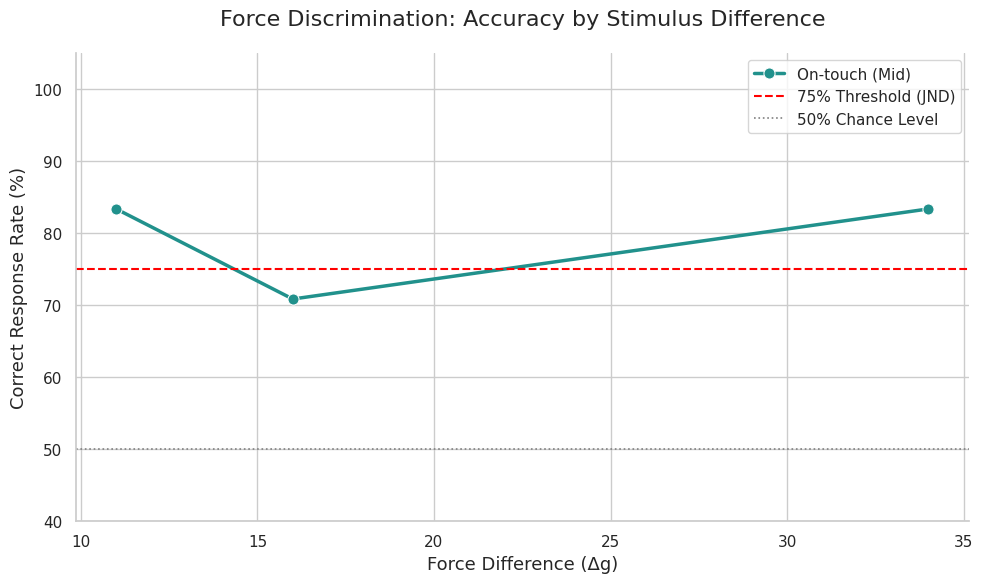

### Overall Accuracy by Condition (%) ###
Condition
On-touch (Mid)    79.166667
Name: IsCorrect_Num, dtype: float64


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 통합 (이전 단계에서 생성된 data_list 사용)
# 만약 코드를 따로 실행하신다면 df = pd.read_csv('파일이름.csv')를 사용하세요.
df = pd.concat(data_list, ignore_index=True)

# 2. 정답 여부(IsCorrect) 계산 로직 추가
# 2AFC 실험에서 '정답'이란 더 강한 자극을 선택하는 것입니다.
def check_correct(row):
    # 비교 자극(Comp)이 기준 자극(Ref)보다 큰 경우 -> 비교 자극을 선택(1)해야 정답
    if row['Comparison'] > row['Reference']:
        return 1 if row['ChoseComparison'] == 1 else 0
    # 비교 자극(Comp)이 기준 자극(Ref)보다 작은 경우 -> 기준 자극을 선택(0)해야 정답
    elif row['Comparison'] < row['Reference']:
        return 1 if row['ChoseComparison'] == 0 else 0
    # 자극이 같은 경우 (1.0 vs 1.0) -> 어느 쪽을 골라도 정답률 계산에서는 0.5(우연)로 처리하거나 제외할 수 있음
    else:
        return 1 if row['UserChoice'] is not None else 0 # 여기서는 응답 여부만 확인

df['IsCorrect_Num'] = df.apply(check_correct, axis=1)

# 3. 자극 간의 '힘의 차이(Force Difference, Δg)' 계산
# 새로운 CSV는 이미 숫자이므로 .replace('g', '') 과정이 필요 없습니다.
df['ForceDiff'] = abs(df['Comparison'] - df['Reference'])

# 4. 조건별/자극차이별 정답률 계산
# 자극 차이가 0인 경우는 JND 계산에서 제외하는 것이 일반적이므로 필터링할 수 있습니다.
analysis_df = df[df['ForceDiff'] > 0].copy()

accuracy_summary = analysis_df.groupby(['Condition', 'ForceDiff'])['IsCorrect_Num'].mean().reset_index()
accuracy_summary['Accuracy_Pct'] = accuracy_summary['IsCorrect_Num'] * 100

# 5. 시각화 (Psychometric Curve)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 선 그래프
sns.lineplot(data=accuracy_summary, x='ForceDiff', y='Accuracy_Pct', hue='Condition',
             marker='o', markersize=8, linewidth=2.5, palette='viridis')

# 75% Threshold 가이드라인 (JND 기준점)
plt.axhline(75, color='red', linestyle='--', linewidth=1.5, label='75% Threshold (JND)')
# 50% Chance Level (무작위 선택 수준)
plt.axhline(50, color='gray', linestyle=':', linewidth=1.2, label='50% Chance Level')

# 그래프 디테일 설정
plt.title('Force Discrimination: Accuracy by Stimulus Difference', fontsize=16, pad=20)
plt.xlabel('Force Difference (Δg)', fontsize=13)
plt.ylabel('Correct Response Rate (%)', fontsize=13)
plt.ylim(40, 105)
plt.legend(frameon=True)
sns.despine()

plt.tight_layout()
plt.show()

# 6. 통계 요약 출력
overall_acc = df.groupby('Condition')['IsCorrect_Num'].mean() * 100
print("### Overall Accuracy by Condition (%) ###")
print(overall_acc)

#x 축에 페어가 오는 전체 코드 (isCorrect 재배열)



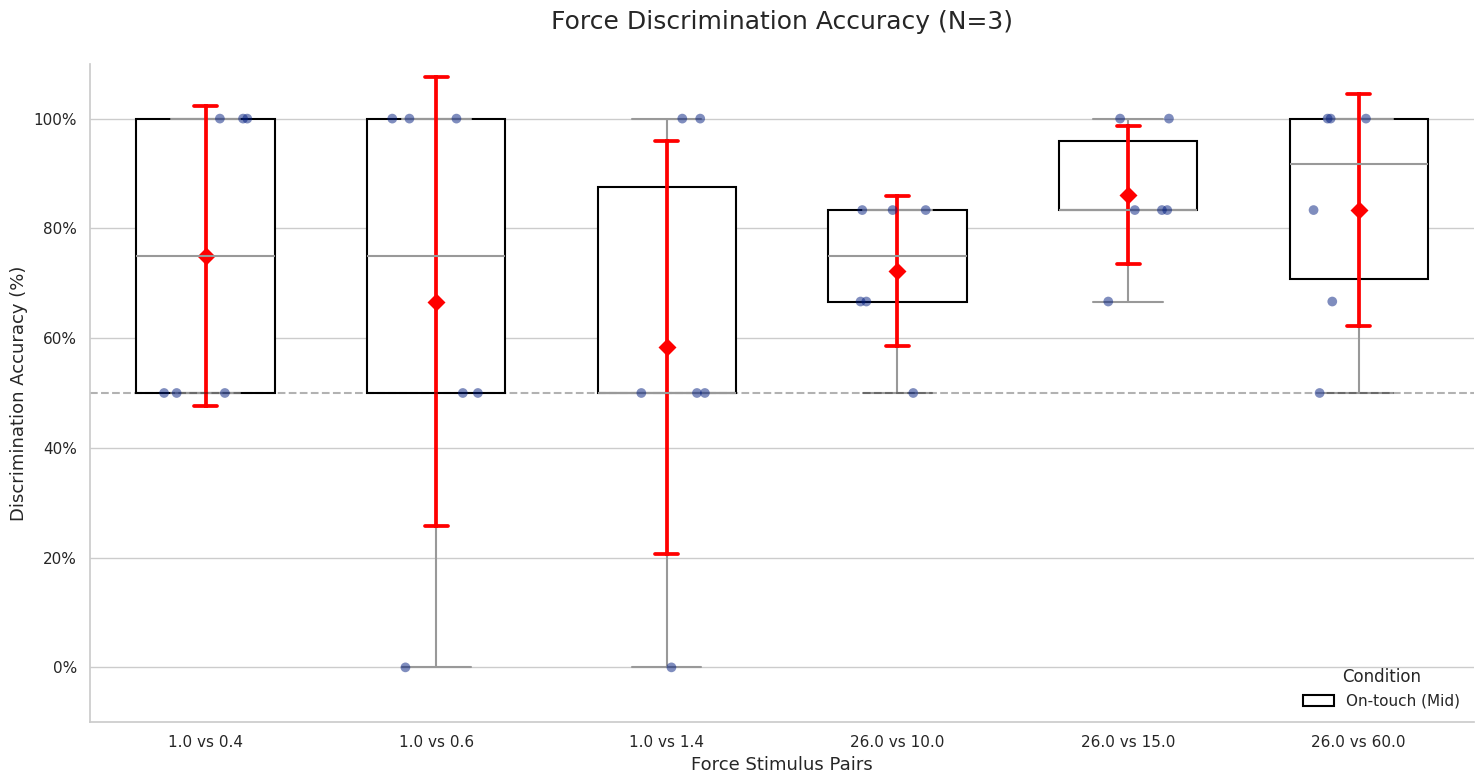

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import glob

# 1. 데이터 로드 및 통합
file_pattern = 'P*_ForceDiscrimination.csv'
file_list = glob.glob(file_pattern)

if not file_list:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in file_list]
    df_merged = pd.concat(df_list, ignore_index=True)

    # 2. 전처리 및 정답 로직
    df_merged['Ref_num'] = pd.to_numeric(df_merged['Reference'])
    df_merged['Comp_num'] = pd.to_numeric(df_merged['Comparison'])
    df_merged['Pair'] = df_merged.apply(lambda x: f"{x['Ref_num']:.1f} vs {x['Comp_num']:.1f}", axis=1)

    def calc_accuracy(row):
        if row['FirstStim'] > row['SecondStim']:
            return 1 if row['UserChoice'] == 1 else 0
        elif row['SecondStim'] > row['FirstStim']:
            return 1 if row['UserChoice'] == 2 else 0
        else:
            return 0.5

    df_merged['IsCorrect'] = df_merged.apply(calc_accuracy, axis=1)

    # 3. 분석 그룹화
    plot_df = df_merged.groupby(['Condition', 'Pair', 'Comp_num', 'Region'])['IsCorrect'].mean().reset_index()
    plot_df['Accuracy (%)'] = plot_df['IsCorrect'] * 100
    pair_order = plot_df.sort_values('Comp_num')['Pair'].unique()

    # --- [중요] 조건 개수에 따른 dodge 및 palette 설정 ---
    unique_conditions = plot_df['Condition'].unique()
    num_cond = len(unique_conditions)

    # 조건이 1개면 dodge를 False(0)로, 2개 이상이면 0.5로 설정
    dodge_val = 0.5 if num_cond > 1 else False
    # 조건 개수에 맞게 팔레트 색상 개수 조절 (경고 방지)
    base_palette = ['#FFFFFF', '#D3D3D3'][:num_cond]

    # 4. 시각화
    plt.figure(figsize=(15, 8))
    sns.set_theme(style="whitegrid")

    # [A] 박스플롯
    sns.boxplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        palette=base_palette,
        width=0.6,
        linewidth=1.5,
        fliersize=0,
        boxprops={'edgecolor': 'black'}
    )

    # [B] 스트립플롯 (dodge_val 적용)
    sns.stripplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=dodge_val,
        palette='dark',
        size=7,
        alpha=0.5,
        jitter=0.2
    )

    # [C] 에러바 (dodge_val 적용 및 FutureWarning 방지용 palette 사용)
    sns.pointplot(
        data=plot_df,
        x='Pair',
        y='Accuracy (%)',
        hue='Condition',
        order=pair_order,
        dodge=dodge_val,
        palette=['red'] * num_cond, # color='red' 대신 palette 사용
        errorbar='sd',
        markers='D',
        linestyle='none',
        capsize=.1
    )

    # 그래프 레이아웃 설정
    num_subjects = df_merged['Subject'].nunique()
    plt.title(f'Force Discrimination Accuracy (N={num_subjects})', fontsize=18, pad=25)
    plt.ylabel('Discrimination Accuracy (%)', fontsize=13)
    plt.xlabel('Force Stimulus Pairs', fontsize=13)

    plt.axhline(50, ls='--', color='black', alpha=0.3, label='Chance (50%)')
    plt.ylim(-10, 110)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

    # 범례 설정 (조건 개수만큼만 표시)
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:num_cond], labels[:num_cond], title='Condition', frameon=False, loc='lower right')

    sns.despine()
    plt.tight_layout()
    plt.show()

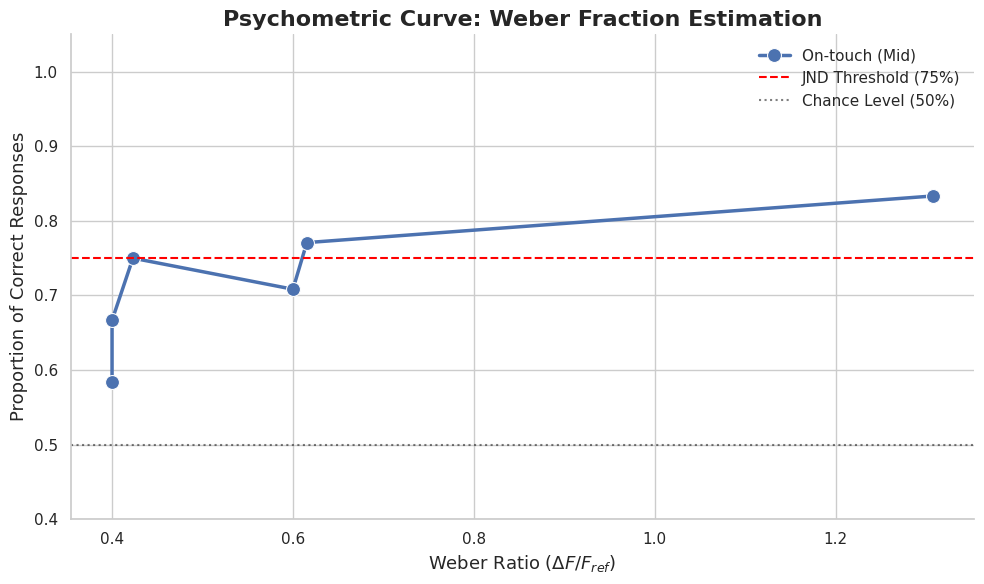


       [Weber Fraction (K) Summary]       
 - On-touch (Mid) Condition K: 0.610


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# 1. 데이터 로드 및 통합 (P*로 시작하는 모든 ForceDiscrimination 파일)
file_pattern = 'P*_ForceDiscrimination*.csv'
all_files = glob.glob(file_pattern)

if not all_files:
    print("CSV 파일을 찾을 수 없습니다.")
else:
    df_list = [pd.read_csv(f) for f in all_files]
    df = pd.concat(df_list, ignore_index=True)

    # 2. IsCorrect 열 생성 (정답 판별 로직)
    def calc_accuracy(row):
        # 첫 번째 자극이 더 큰 경우 -> 유저가 1번을 골라야 정답
        if row['FirstStim'] > row['SecondStim']:
            return 1 if row['UserChoice'] == 1 else 0
        # 두 번째 자극이 더 큰 경우 -> 유저가 2번을 골라야 정답
        elif row['SecondStim'] > row['FirstStim']:
            return 1 if row['UserChoice'] == 2 else 0
        # 두 자극이 같은 경우 (Ref vs Ref) -> 우연(0.5) 처리
        else:
            return 0.5

    df['IsCorrect'] = df.apply(calc_accuracy, axis=1)

    # 3. WeberRatio 컬럼 생성
    # Weber Ratio = |Reference - Comparison| / Reference
    df['WeberRatio'] = abs(df['Reference'] - df['Comparison']) / df['Reference']

    # 4. Psychometric Curve 데이터 계산
    psychometric_data = df.groupby(['Condition', 'WeberRatio'])['IsCorrect'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    # 시각화 (라인 플롯)
    sns.lineplot(data=psychometric_data, x='WeberRatio', y='IsCorrect', hue='Condition', marker='o', markersize=10, linewidth=2.5)

    # JND 기준선 (75%)
    plt.axhline(0.75, color='red', linestyle='--', label='JND Threshold (75%)')
    # Chance level (50%)
    plt.axhline(0.50, color='black', linestyle=':', alpha=0.5, label='Chance Level (50%)')

    plt.title('Psychometric Curve: Weber Fraction Estimation', fontsize=16, fontweight='bold')
    plt.xlabel(r'Weber Ratio ($\Delta F / F_{ref}$)', fontsize=13)
    plt.ylabel('Proportion of Correct Responses', fontsize=13)
    plt.ylim(0.4, 1.05)
    plt.legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5. Weber Fraction (K) 결과 출력
    print("\n" + "="*40)
    print("       [Weber Fraction (K) Summary]       ")
    print("="*40)

    psychometric_data = psychometric_data.sort_values('WeberRatio')

    for cond in df['Condition'].unique():
        cond_df = psychometric_data[psychometric_data['Condition'] == cond]

        if len(cond_df) >= 2:
            # 선형 보간을 통한 75% 정답률 지점(Weber Fraction) 계산
            k_est = np.interp(0.75, cond_df['IsCorrect'], cond_df['WeberRatio'])
            print(f" - {cond} Condition K: {k_est:.3f}")
        else:
            print(f" - {cond} Condition: 데이터 포인트 부족으로 추정 불가")